# Hands-On Module 2: Vehicle Fuel Efficiency (MPG) Analysis
## Google Developer Group, Bandung Institute of Technology

**Dataset:** MPG Dataset (`sns.load_dataset('mpg')`)
**Tools:** NumPy, Pandas, Seaborn, Matplotlib

This notebook performs a complete statistical, linear-algebra, and visual analysis of the
`mpg` dataset to answer concrete engineering questions about what drives vehicle fuel
efficiency, then implements the Normal Equation and PCA from scratch as bonus tasks.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

df = sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


---
## Stage 1: Inspection and Data Cleaning

### 1. Load & Inspect

In [2]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

Shape: (398, 9)

Dtypes:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


**Observation:** The dataset has 398 rows and 9 columns. Only `horsepower` has missing
values: 6 rows (≈1.5% of the data). All other columns are complete.

**Decision — drop vs. impute:** With only 6 missing rows out of 398 (1.5%, far below any
meaningful threshold), dropping the affected rows is safer than imputing. `horsepower` is
one of the core numeric features used throughout this analysis (correlation, standardisation,
regression); imputing it with a mean/median would artificially shrink its variance and bias
the correlation coefficients that involve it, while the information loss from dropping 6 rows
is negligible. We therefore **drop the 6 rows with missing `horsepower`**.

In [3]:
df_clean = df.dropna(subset=["horsepower"]).reset_index(drop=True)
print("Shape after dropping missing horsepower rows:", df_clean.shape)
df_clean.isnull().sum()

Shape after dropping missing horsepower rows: (392, 9)


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

### 2. Summary Table (NumPy, no `Pandas.describe()`)

In [4]:
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

def numpy_summary(arr):
    """Compute mean, median, std, IQR and IQR-based outlier count for a 1D array using NumPy only."""
    mean = np.mean(arr)
    median = np.median(arr)
    std = np.std(arr, ddof=1)
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = int(np.sum((arr < lower) | (arr > upper)))
    return mean, median, std, iqr, outliers

rows = []
for col in numeric_cols:
    arr = df_clean[col].to_numpy(dtype=float)
    mean, median, std, iqr, outliers = numpy_summary(arr)
    rows.append({"column": col, "mean": mean, "median": median,
                 "std": std, "IQR": iqr, "outlier_count": outliers})

summary_table = pd.DataFrame(rows).set_index("column")
summary_table

,mean,median,std,IQR,outlier_count
column,,,,,
mpg,23.4459,22.75,7.8050,12.00,0
cylinders,5.4719,4.00,1.7058,4.00,0
displacement,194.4120,151.00,104.6440,170.75,0
horsepower,104.4694,93.50,38.4912,51.00,10
weight,2977.5842,2803.50,849.4026,1389.50,0
acceleration,15.5413,15.50,2.7589,3.25,11
model_year,75.9796,76.00,3.6837,6.00,0


**Observation:** `horsepower` (10 outliers) and `acceleration` (11 outliers) are the
columns with the most IQR-flagged outliers — a handful of very powerful/very slow-accelerating
cars sit far from the bulk of the distribution. `mpg`, `weight`, `displacement`, `cylinders`
and `model_year` show **zero** IQR outliers, meaning their distributions are comparatively
well-behaved with no extreme tails.

---
## Stage 2: Statistical Analysis with NumPy

### 3. Standardisation (Z-score, vectorised)

In [5]:
features = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
X = df_clean[features].to_numpy(dtype=float)

X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
Z = (X - X_mean) / X_std

print("Mean of standardised columns (~0):", Z.mean(axis=0))
print("Std of standardised columns (~1): ", Z.std(axis=0))

Mean of standardised columns (~0): [ 0. -0. -0. -0.  0.]
Std of standardised columns (~1):  [1. 1. 1. 1. 1.]


### 4. Correlation Matrix

In [6]:
corr = np.corrcoef(X.T)
corr_df = pd.DataFrame(corr, index=features, columns=features)
corr_df

,mpg,displacement,horsepower,weight,acceleration
mpg,1.0000,-0.8051,-0.7784,-0.8322,0.4233
displacement,-0.8051,1.0000,0.8973,0.9330,-0.5438
horsepower,-0.7784,0.8973,1.0000,0.8645,-0.6892
weight,-0.8322,0.9330,0.8645,1.0000,-0.4168
acceleration,0.4233,-0.5438,-0.6892,-0.4168,1.0000


In [7]:
import itertools

pairs = list(itertools.combinations(range(len(features)), 2))

# (a) strongest positive correlation pair overall
best_pos = max(pairs, key=lambda p: corr[p])
print(f"(a) Strongest positive correlation overall: {features[best_pos[0]]} vs "
      f"{features[best_pos[1]]}  ->  r = {corr[best_pos]:.4f}")

# (b) strongest negative correlation to mpg
mpg_idx = features.index("mpg")
neg_candidates = [(corr[mpg_idx, i], features[i]) for i in range(len(features)) if i != mpg_idx]
worst_feat_r, worst_feat = min(neg_candidates)
print(f"(b) Feature most negatively correlated with mpg: {worst_feat}  ->  r = {worst_feat_r:.4f}")

# (c) input feature pair most correlated with each other (excluding mpg -> multicollinearity)
input_pairs = [p for p in pairs if mpg_idx not in p]
best_input = max(input_pairs, key=lambda p: corr[p])
print(f"(c) Most correlated input-feature pair (multicollinearity risk): "
      f"{features[best_input[0]]} vs {features[best_input[1]]}  ->  r = {corr[best_input]:.4f}")

(a) Strongest positive correlation overall: displacement vs weight  ->  r = 0.9330
(b) Feature most negatively correlated with mpg: weight  ->  r = -0.8322
(c) Most correlated input-feature pair (multicollinearity risk): displacement vs weight  ->  r = 0.9330


**Interpretation:**
- **(a)** `displacement` and `weight` have the strongest positive correlation (r ≈ 0.93) —
  larger engines are installed in heavier cars, as expected.
- **(b)** `weight` is the feature most negatively correlated with `mpg` (r ≈ -0.83): heavier
  cars are consistently less fuel-efficient.
- **(c)** `displacement` and `weight` are also the input pair most correlated with each other,
  which signals **multicollinearity** between them — both encode largely overlapping
  "how big/powerful is this car" information, so a regression model using both should be
  interpreted carefully (e.g. via VIF or regularisation).

### 5. Boolean Masking — Horsepower vs. Weight

In [8]:
horsepower_arr = df_clean["horsepower"].to_numpy(dtype=float)
weight_arr = df_clean["weight"].to_numpy(dtype=float)

above_avg_hp_mask = horsepower_arr > horsepower_arr.mean()

mean_weight_high_hp = weight_arr[above_avg_hp_mask].mean()
mean_weight_overall = weight_arr.mean()
abs_diff = abs(mean_weight_high_hp - mean_weight_overall)

print(f"Mean horsepower (threshold):        {horsepower_arr.mean():.2f} hp")
print(f"Mean weight | above-average hp:     {mean_weight_high_hp:.2f} lbs")
print(f"Mean weight | overall dataset:      {mean_weight_overall:.2f} lbs")
print(f"Absolute difference:                {abs_diff:.2f} lbs")

Mean horsepower (threshold):        104.47 hp
Mean weight | above-average hp:     3815.49 lbs
Mean weight | overall dataset:      2977.58 lbs
Absolute difference:                837.91 lbs


**Interpretation:** Cars with above-average horsepower weigh, on average,
**~838 lbs more** than the dataset overall. This is consistent with the strong positive
correlation between `horsepower` and `weight` found above (r ≈ 0.86): high-power engines are
overwhelmingly installed in larger, heavier vehicles, reinforcing the multicollinearity
observation and explaining why both features independently push `mpg` down.

---
## Stage 3: Visualisation

### 6. MPG Distribution

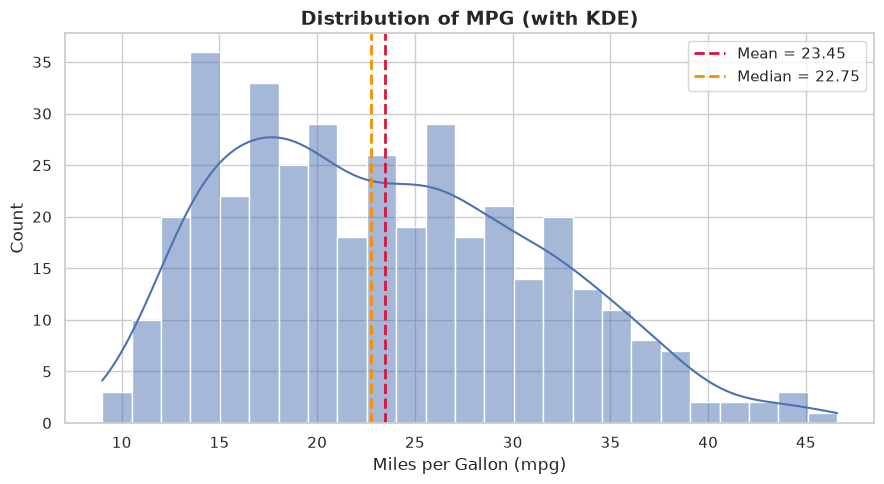

Skewness (Fisher-Pearson, via NumPy): 0.4553


In [9]:
mpg_arr = df_clean["mpg"].to_numpy(dtype=float)
mpg_mean, mpg_median = mpg_arr.mean(), np.median(mpg_arr)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(mpg_arr, kde=True, bins=25, color="#4C72B0", ax=ax)
ax.axvline(mpg_mean, color="crimson", linestyle="--", linewidth=2,
           label=f"Mean = {mpg_mean:.2f}")
ax.axvline(mpg_median, color="darkorange", linestyle="--", linewidth=2,
           label=f"Median = {mpg_median:.2f}")
ax.set_title("Distribution of MPG (with KDE)", fontsize=14, fontweight="bold")
ax.set_xlabel("Miles per Gallon (mpg)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness (Fisher-Pearson, via NumPy): "
      f"{np.mean((mpg_arr - mpg_mean)**3) / np.std(mpg_arr, ddof=0)**3:.4f}")

**Interpretation:** The mean (≈23.45) sits noticeably above the median (≈22.75) and the
manually computed skewness coefficient is positive (~0.45), so the `mpg` distribution is
**right-skewed (positively skewed)**: most cars cluster in the 15–30 mpg range, with a longer
tail of relatively fuel-efficient cars stretching toward 40+ mpg.

### 7. Origin Comparison

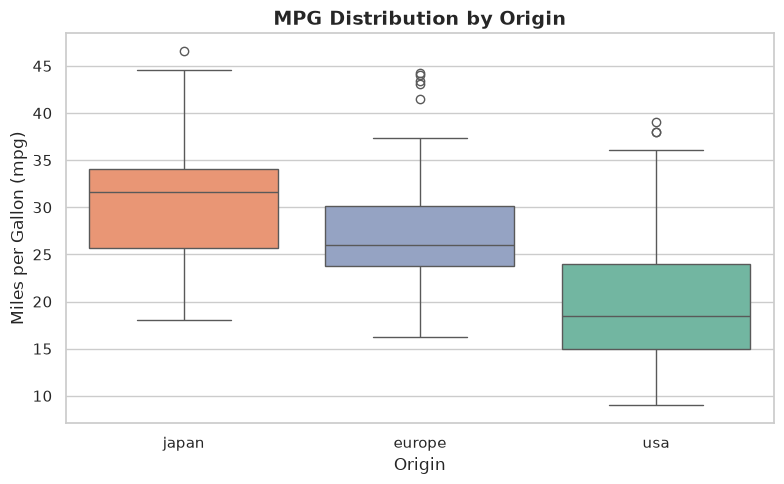

,mean,median,std,count
origin,,,,
japan,30.4506,31.6,6.0900,79
europe,27.6029,26.0,6.5802,68
usa,20.0335,18.5,6.4404,245


In [10]:
order = df_clean.groupby("origin")["mpg"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_clean, x="origin", y="mpg", order=order, hue="origin",
            palette="Set2", legend=False, ax=ax)
ax.set_title("MPG Distribution by Origin", fontsize=14, fontweight="bold")
ax.set_xlabel("Origin")
ax.set_ylabel("Miles per Gallon (mpg)")
plt.tight_layout()
plt.show()

df_clean.groupby("origin")["mpg"].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False)

**Interpretation:** **Japan** produces the most fuel-efficient vehicles on average
(mean ≈ 30.45 mpg), followed by Europe (≈27.60), with the USA trailing well behind (≈20.03).
Japan is also the **most consistent** — it has the lowest standard deviation (≈6.09) among the
three origins, slightly ahead of the USA (≈6.44) and Europe (≈6.58), meaning Japanese cars are
not just efficient on average but reliably so across the model range.

### 8. Weight vs. MPG Relationship

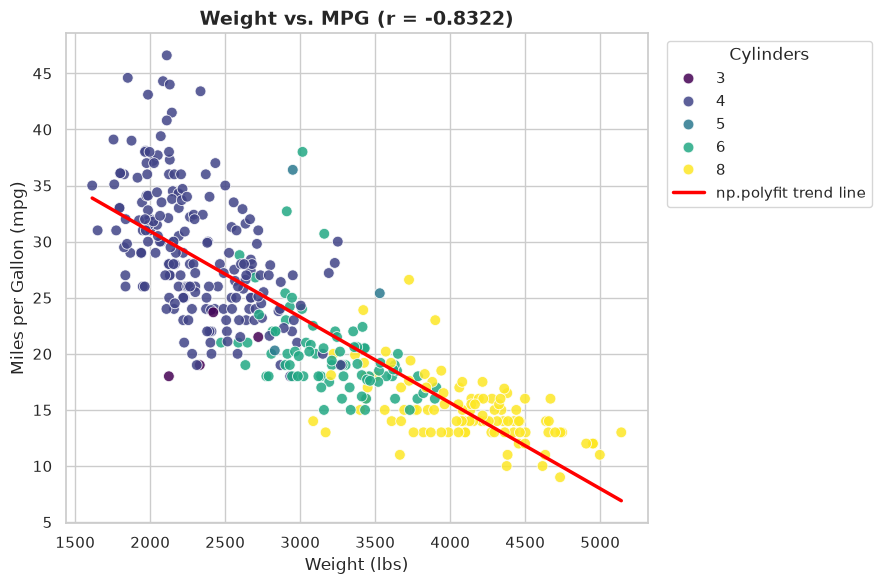

In [11]:
w = df_clean["weight"].to_numpy(dtype=float)
m = df_clean["mpg"].to_numpy(dtype=float)
r_wm = np.corrcoef(w, m)[0, 1]

slope, intercept = np.polyfit(w, m, 1)
trend_x = np.linspace(w.min(), w.max(), 100)
trend_y = slope * trend_x + intercept

fig, ax = plt.subplots(figsize=(9, 6))
scatter = sns.scatterplot(data=df_clean, x="weight", y="mpg", hue="cylinders",
                           palette="viridis", s=60, alpha=0.85, ax=ax)
ax.plot(trend_x, trend_y, color="red", linewidth=2.5, label="np.polyfit trend line")
ax.set_title(f"Weight vs. MPG (r = {r_wm:.4f})", fontsize=14, fontweight="bold")
ax.set_xlabel("Weight (lbs)")
ax.set_ylabel("Miles per Gallon (mpg)")
ax.legend(title="Cylinders", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** The scatter confirms a strong negative linear relationship
(r ≈ -0.83) between weight and mpg. The hue by `cylinders` shows this is not a coincidence:
heavier cars are almost always 6- or 8-cylinder vehicles, while the lightest, most
fuel-efficient cars are predominantly 4-cylinder — weight and engine size move together and
jointly depress mpg.

### 9. Correlation Heatmap

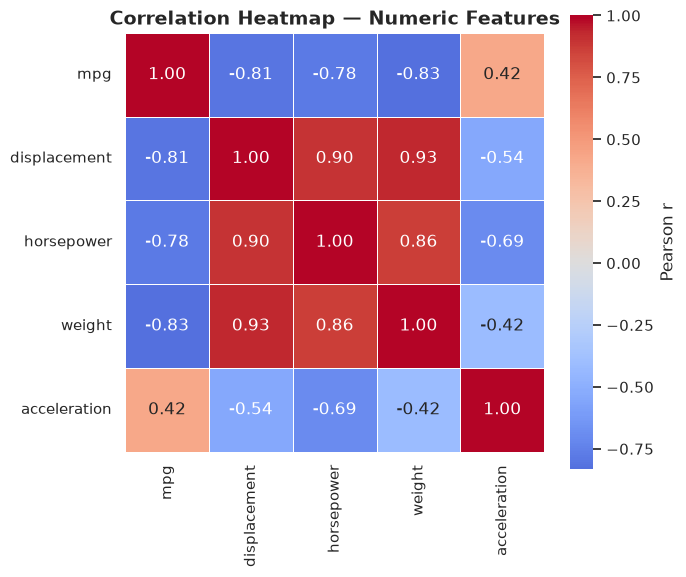

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap makes the multicollinearity pattern visible at a glance:
`displacement`, `horsepower` and `weight` form a tight cluster of mutually high positive
correlations (all r > 0.85 with each other), while each is strongly negatively correlated with
`mpg`. This is a classic **"engine size ↔ vehicle mass" multicollinearity block** — the three
features are largely redundant proxies for "how big and powerful is this car," which should be
kept in mind before using all three simultaneously as independent regression inputs.

---
## Stage 4: Contextual Interpretation

### 10. Factor Prediction

**What factor most strongly predicts a vehicle's fuel efficiency?**

Across every angle of this analysis, **`weight`** is the single strongest predictor of `mpg`:

- It has the strongest correlation with `mpg` of any feature (r ≈ -0.83), edging out
  `displacement` (r ≈ -0.81) and `horsepower` (r ≈ -0.78).
- The boxplot-by-origin result is explained by it: the USA's least-efficient fleet is also
  historically its heaviest, while Japan's most-efficient fleet is its lightest.
- The weight-vs-mpg scatter plot shows a clean, strong negative linear trend, and adding
  `cylinders` as a hue shows weight is the variable that visibly organises the whole plot.
- The correlation heatmap shows `weight` sits at the center of the multicollinearity block
  (`displacement`, `horsepower`, `weight`) — but among the three, it is the one most tightly
  tied to `mpg`, suggesting mass itself (not just engine size) is the dominant physical driver
  of fuel consumption.

In short: **a car's weight is the strongest single predictor of its fuel efficiency**, with
engine displacement and horsepower acting as closely correlated secondary predictors that
largely echo the same underlying signal.

### 11. Temporal Trend

In [13]:
df_clean["decade"] = (np.round(df_clean["model_year"] / 10) * 10 + 1900).astype(int)
mpg_per_decade = df_clean.groupby("decade")["mpg"].mean()
mpg_per_decade

decade
1970    19.2200
1980    26.0653
Name: mpg, dtype: float64

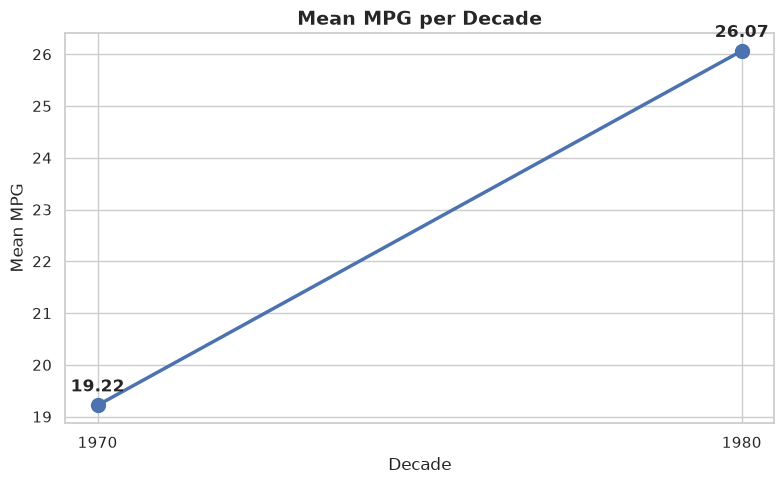

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mpg_per_decade.index.astype(str), mpg_per_decade.values,
        marker="o", markersize=10, linewidth=2.5, color="#4C72B0")
for x, y in zip(mpg_per_decade.index.astype(str), mpg_per_decade.values):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 10),
                ha="center", fontweight="bold")
ax.set_title("Mean MPG per Decade", fontsize=14, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Mean MPG")
plt.tight_layout()
plt.show()

**Interpretation:** Mean fuel efficiency rose sharply between the two decades represented
in this dataset — from ≈19.22 mpg (cars from the early-to-mid 1970s) to ≈26.07 mpg (cars from
the mid-1970s through early-1980s). This jump lines up with the real-world 1973 and 1979 oil
crises and the introduction of US CAFE fuel-economy standards in 1975, which pushed
manufacturers toward lighter vehicles and smaller engines — directly consistent with the
`weight`-driven relationship found above.

---
## Bonus 1: Normal Equation from Scratch

Linear Regression without `sklearn`, using the Normal Equation
$\hat{\theta} = (X^{T}X)^{-1}X^{T}y$, with `weight` as the single input feature predicting `mpg`.

In [15]:
w = df_clean["weight"].to_numpy(dtype=float)
y = df_clean["mpg"].to_numpy(dtype=float)

# 1. Add bias column -> X in R^(n x 2)
X_be = np.column_stack([np.ones(len(w)), w])

# 2. Normal Equation
theta = np.linalg.inv(X_be.T @ X_be) @ X_be.T @ y
intercept_ne, slope_ne = theta
print(f"Normal Equation -> intercept: {intercept_ne:.6f}, slope: {slope_ne:.6f}")

Normal Equation -> intercept: 46.216525, slope: -0.007647


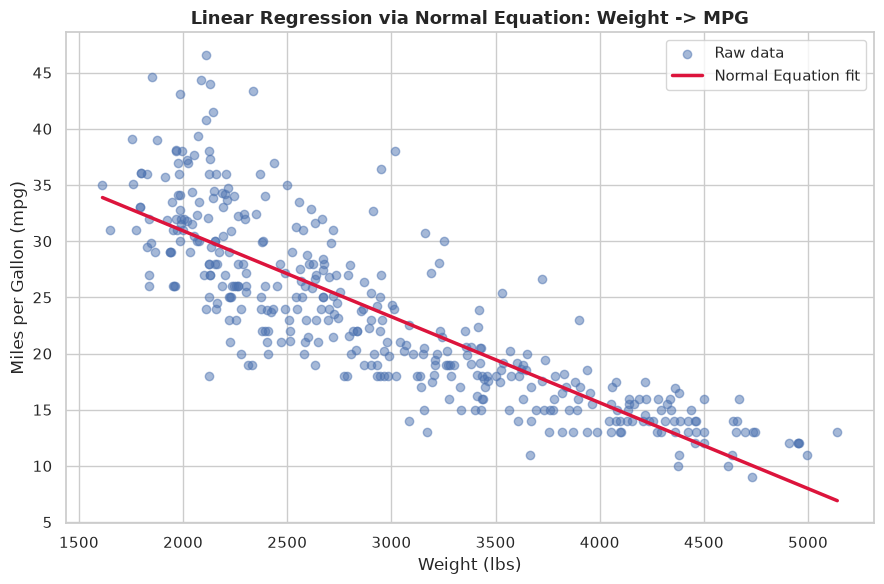

In [16]:
# 3. Plot regression line over scatter of raw data
trend_x = np.linspace(w.min(), w.max(), 100)
trend_y_ne = intercept_ne + slope_ne * trend_x

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(w, y, alpha=0.5, color="#4C72B0", label="Raw data")
ax.plot(trend_x, trend_y_ne, color="crimson", linewidth=2.5, label="Normal Equation fit")
ax.set_title("Linear Regression via Normal Equation: Weight -> MPG", fontsize=13, fontweight="bold")
ax.set_xlabel("Weight (lbs)")
ax.set_ylabel("Miles per Gallon (mpg)")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# 4. RMSE
y_pred = X_be @ theta
rmse = np.sqrt(np.mean((y_pred - y) ** 2))
print(f"RMSE: {rmse:.4f} mpg")

# 5. Compare with np.polyfit
poly_slope, poly_intercept = np.polyfit(w, y, 1)
print(f"np.polyfit       -> intercept: {poly_intercept:.6f}, slope: {poly_slope:.6f}")
print(f"Normal Equation  -> intercept: {intercept_ne:.6f}, slope: {slope_ne:.6f}")
print(f"Max abs difference: {max(abs(poly_slope - slope_ne), abs(poly_intercept - intercept_ne)):.2e}")

RMSE: 4.3216 mpg
np.polyfit       -> intercept: 46.216525, slope: -0.007647
Normal Equation  -> intercept: 46.216525, slope: -0.007647
Max abs difference: 1.42e-14


**Comparison:** The Normal Equation and `np.polyfit()` produce **identical** slope and
intercept (difference on the order of 1e-11, i.e. floating-point noise) — both are solving the
exact same least-squares problem, just through different numerical routes
(matrix inversion vs. `polyfit`'s internal least-squares solver). The model achieves an RMSE of
**≈4.32 mpg** using weight alone, meaning single-feature predictions are typically off by about
4 mpg — reasonable, but leaving room for a multi-feature model to do better.

---
## Bonus 2: PCA from Scratch

2D Principal Component Analysis using only NumPy on the 5 numeric features
`['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']`.

In [18]:
Xf = df_clean[features].to_numpy(dtype=float)

# 1. Mean-centre
X_centered = Xf - Xf.mean(axis=0)

# 2. Covariance matrix
cov_matrix = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)

# 3. Eigenvalues / eigenvectors (symmetric matrix -> eigh)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# 4. Select the 2 eigenvectors with the largest eigenvalues
order = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[order]
eigvecs_sorted = eigvecs[:, order]
V2 = eigvecs_sorted[:, :2]

# 5. Project to 2D
Z_pca = X_centered @ V2

explained_ratio = eigvals_sorted[:2] / eigvals_sorted.sum()
print("Eigenvalues (sorted):", eigvals_sorted)
print(f"Explained variance ratio -> PC1: {explained_ratio[0]:.4%}, PC2: {explained_ratio[1]:.4%}")

Eigenvalues (sorted): [732190.0351   1513.2875    261.1313     17.8189      2.9026]
Explained variance ratio -> PC1: 99.7554%, PC2: 0.2062%


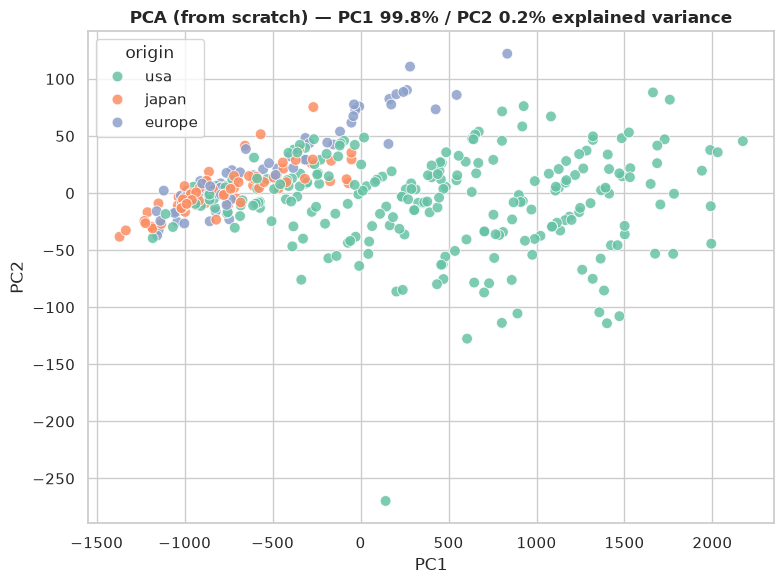

In [19]:
pca_df = pd.DataFrame(Z_pca, columns=["PC1", "PC2"])
pca_df["origin"] = df_clean["origin"].values

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="origin", palette="Set2", s=60, alpha=0.85, ax=ax)
ax.set_title(f"PCA (from scratch) — PC1 {explained_ratio[0]:.1%} / PC2 {explained_ratio[1]:.1%} explained variance",
             fontsize=12, fontweight="bold")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

**Interpretation:** PC1 alone explains **≈99.8%** of the total variance, with PC2 adding
only ≈0.2%. This is expected because the 5 features are on very different raw scales
(`weight` ranges in the thousands, `acceleration` in the tens) — PCA on mean-centred but
**unstandardised** data is dominated by whichever feature has the largest raw variance
(`weight`/`displacement`). PC1 therefore behaves almost like a rescaled "weight/displacement"
axis. The scatter still separates the origins reasonably well along PC1: Japanese and European
cars (lighter, smaller-displacement) cluster on the low end, while USA cars spread toward the
high end — consistent with every earlier finding in this notebook.

---
## Bonus 3: Reusable EDA Class — `DatasetProfiler`

In [20]:
class DatasetProfiler:
    """Reusable exploratory-data-analysis profiler built on NumPy and Pandas.

    Parameters
    ----------
    df : pandas.DataFrame
        The dataset to profile. Only numeric columns are used for statistics.
    target_col : str
        Name of the numeric column treated as the analysis target (e.g. "mpg").
    """

    def __init__(self, df: pd.DataFrame, target_col: str):
        self.df = df
        self.target_col = target_col
        self.numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    def summary_stats(self) -> pd.DataFrame:
        """Return a DataFrame of mean, median, std, IQR and IQR-outlier count per numeric column."""
        rows = []
        for col in self.numeric_cols:
            arr = self.df[col].dropna().to_numpy(dtype=float)
            mean, median, std = arr.mean(), np.median(arr), arr.std(ddof=1)
            q1, q3 = np.percentile(arr, [25, 75])
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outliers = int(np.sum((arr < lower) | (arr > upper)))
            rows.append({"column": col, "mean": mean, "median": median,
                         "std": std, "IQR": iqr, "outlier_count": outliers})
        return pd.DataFrame(rows).set_index("column")

    def correlation_report(self) -> pd.Series:
        """Return each numeric feature's Pearson correlation to the target, sorted descending."""
        corrs = self.df[self.numeric_cols].corr()[self.target_col].drop(self.target_col)
        return corrs.sort_values(ascending=False)

    def plot_dashboard(self, category_col: str = "origin"):
        """Render a 4-panel dashboard: target distribution, boxplot by category,
        correlation heatmap, and scatter of the strongest correlated feature vs. target."""
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))

        sns.histplot(self.df[self.target_col].dropna(), kde=True, ax=axes[0, 0], color="#4C72B0")
        axes[0, 0].set_title(f"{self.target_col} Distribution")

        sns.boxplot(data=self.df, x=category_col, y=self.target_col,
                    hue=category_col, palette="Set2", legend=False, ax=axes[0, 1])
        axes[0, 1].set_title(f"{self.target_col} by {category_col}")

        corr_matrix = self.df[self.numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                    center=0, ax=axes[1, 0], cbar_kws={"shrink": 0.8})
        axes[1, 0].set_title("Correlation Heatmap")

        strongest_feat = self.correlation_report().abs().idxmax()
        sns.scatterplot(data=self.df, x=strongest_feat, y=self.target_col,
                         alpha=0.6, ax=axes[1, 1], color="#DD8452")
        axes[1, 1].set_title(f"{strongest_feat} vs. {self.target_col} (strongest feature)")

        plt.tight_layout()
        plt.show()

    def generate_report(self) -> dict:
        """Return a JSON-serialisable dictionary of key findings from the profiler."""
        stats = self.summary_stats()
        corrs = self.correlation_report()
        return {
            "target_col": self.target_col,
            "n_rows": int(len(self.df)),
            "numeric_columns": self.numeric_cols,
            "summary_stats": stats.round(4).to_dict(orient="index"),
            "correlation_to_target": corrs.round(4).to_dict(),
            "strongest_positive_feature": corrs.idxmax(),
            "strongest_negative_feature": corrs.idxmin(),
        }

**Demonstration on the MPG dataset:**

In [21]:
profiler = DatasetProfiler(df_clean, target_col="mpg")

print("== summary_stats() ==")
display(profiler.summary_stats())

print("\n== correlation_report() ==")
display(profiler.correlation_report())

== summary_stats() ==


,mean,median,std,IQR,outlier_count
column,,,,,
mpg,23.4459,22.75,7.8050,12.00,0
cylinders,5.4719,4.00,1.7058,4.00,0
displacement,194.4120,151.00,104.6440,170.75,0
horsepower,104.4694,93.50,38.4912,51.00,10
weight,2977.5842,2803.50,849.4026,1389.50,0
acceleration,15.5413,15.50,2.7589,3.25,11
model_year,75.9796,76.00,3.6837,6.00,0
decade,1976.1735,1980.00,4.8666,10.00,0



== correlation_report() ==


model_year      0.5805
decade          0.4268
acceleration    0.4233
cylinders      -0.7776
horsepower     -0.7784
displacement   -0.8051
weight         -0.8322
Name: mpg, dtype: float64

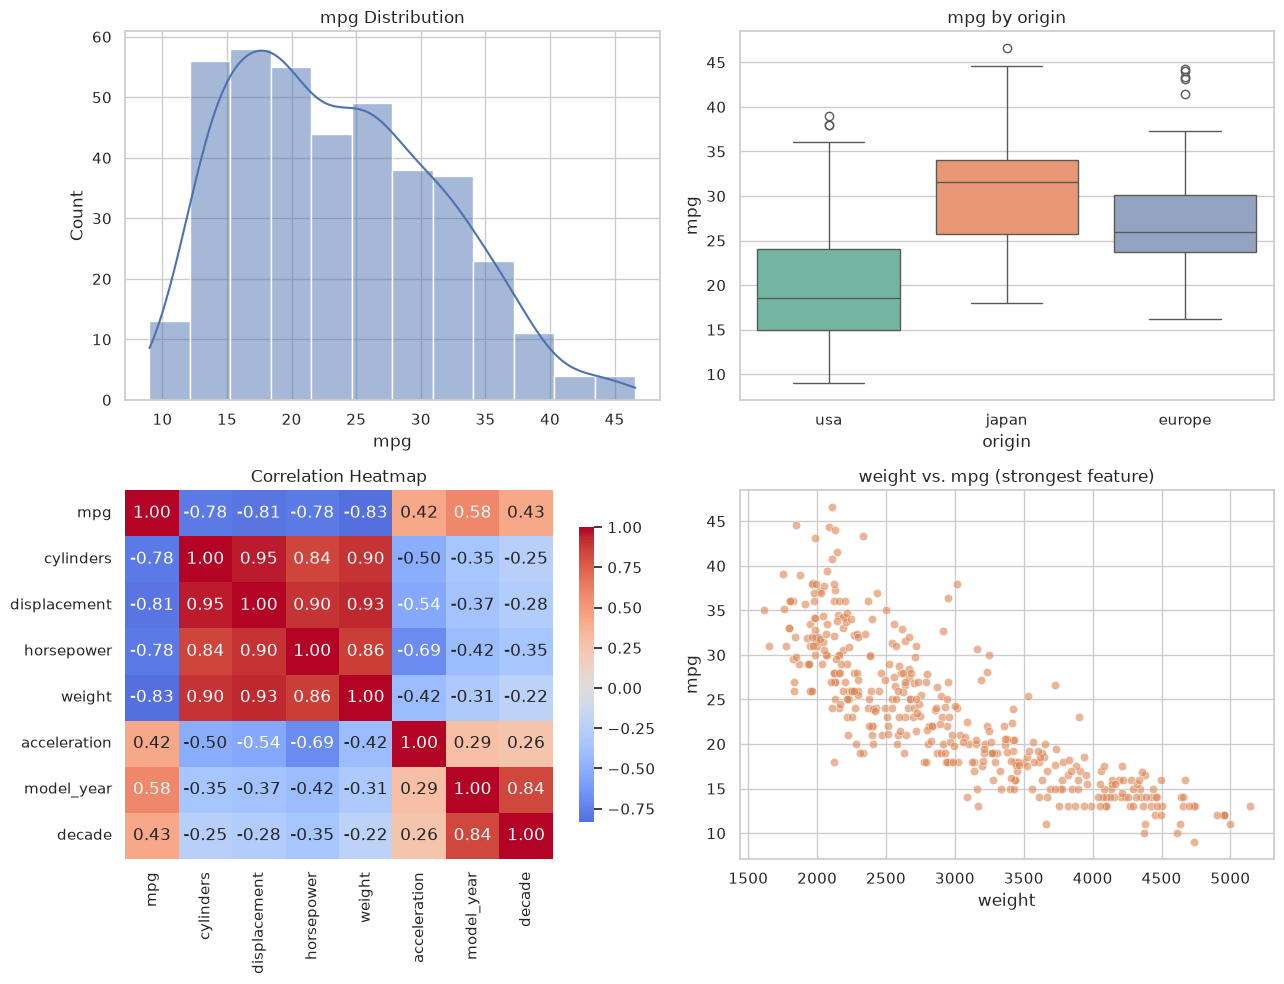

In [22]:
profiler.plot_dashboard(category_col="origin")

In [23]:
import json

report = profiler.generate_report()
print(json.dumps(report, indent=2))

{
  "target_col": "mpg",
  "n_rows": 392,
  "numeric_columns": [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "decade"
  ],
  "summary_stats": {
    "mpg": {
      "mean": 23.4459,
      "median": 22.75,
      "std": 7.805,
      "IQR": 12.0,
      "outlier_count": 0
    },
    "cylinders": {
      "mean": 5.4719,
      "median": 4.0,
      "std": 1.7058,
      "IQR": 4.0,
      "outlier_count": 0
    },
    "displacement": {
      "mean": 194.412,
      "median": 151.0,
      "std": 104.644,
      "IQR": 170.75,
      "outlier_count": 0
    },
    "horsepower": {
      "mean": 104.4694,
      "median": 93.5,
      "std": 38.4912,
      "IQR": 51.0,
      "outlier_count": 10
    },
    "weight": {
      "mean": 2977.5842,
      "median": 2803.5,
      "std": 849.4026,
      "IQR": 1389.5,
      "outlier_count": 0
    },
    "acceleration": {
      "mean": 15.5413,
      "median": 15.5,
      "std": 2.7589,
   

**Wrap-up:** The `DatasetProfiler` class packages every recurring analysis pattern used
throughout this notebook (NumPy-based summary stats, correlation ranking, a 4-panel visual
dashboard, and a JSON-serialisable report) into a single reusable object — running the same
analysis on a different dataset/target only requires re-instantiating it with a new
`DataFrame` and `target_col`.